# Expected decoding uncertainty: aggregation

Aggregates the per-subject TSVs written by `get_expected_uncertainty.py` (models 15/18/31, smoothed, spherical noise, with/without `many_samples` and `wide`) into `derivatives/expected_uncertainty/expected_uncertainty.tsv`, which feeds `behavior_vs_fmri.ipynb` (Fig. 5b), and sanity-checks the result (completeness table plus plots of expected posterior mean/variance by numerosity, model, and settings).

In [29]:
import pandas as pd
from braincoder.models import GaussianPRF

import numpy as np

from neural_priors.utils.data import Subject
from neural_priors.encoding_model.fit_model import get_paradigm, get_model
from pathlib import Path

from braincoder.utils import get_rsq
from braincoder.utils.math import get_expected_value, get_sd_posterior
from braincoder.optimize import ResidualFitter
from tqdm.contrib.itertools import product
import seaborn as sns

In [30]:
bids_folder = Path('/data/ds-neuralpriors')

subjects = list(range(1, 42))
# subjects.remove(23)

model_labels =[15, 18, 31]
fit_responses = [False]
many_samples = [False, True]
wide = [False, True]

smoothed = True

E = []
sd = []
keys = [] 

pars = []

for subject, model_label, fit_response, spherical_noise, many_samples_, wide_ in product(subjects, model_labels, fit_responses, [True], many_samples, wide):

        # Create target folder
    key = f'model{model_label}'

    if smoothed:
        key += '.smoothed'

    if spherical_noise:
        key += '.spherical_noise'

    if fit_response:
        key += '.fit_responses'

    if wide_:
        key += '.wide'

    d = 'expected_uncertainty'

    if not many_samples_:
        d += '.bak'

    target_dir = Path(bids_folder) / 'derivatives' / d / key / f'sub-{subject:02d}' / 'func'

    try:
        # fi = pd.read_csv(target_dir / f'sub-{subject:02d}_desc-fisher_information.tsv', sep='\t')

        pars.append(pd.read_csv(target_dir / f'sub-{subject:02d}_desc-expected_error.tsv', sep='\t'))

    except FileNotFoundError as e:
        print(f'File not found for subject {subject}, model {model_label}, fit_response {fit_response}: {e}')
    
        continue

    # fisher_information.append(fi)
    keys.append((subject , model_label, fit_response, smoothed, spherical_noise, many_samples_, wide_))

# Concatenate all dataframes
# fisher_information = pd.concat(fisher_information, keys=keys, names=['subject', 'model_label', 'fit_response', 'smoothed'])
# E = pd.concat(E, keys=keys, names=['subject', 'model_label', 'fit_response', 'smoothed', 'spherical_noise', 'many_samples'])
# sd = pd.concat(sd, keys=keys, names=['subject', 'model_label', 'fit_response', 'smoothed', 'spherical_noise', 'many_samples'])

pars = pd.concat(pars, keys=keys, names=['subject', 'model_label', 'fit_response', 'smoothed', 'spherical_noise', 'many_samples', 'wide'])

  0%|          | 0/492 [00:00<?, ?it/s]

File not found for subject 1, model 15, fit_response False: [Errno 2] No such file or directory: '/data/ds-neuralpriors/derivatives/expected_uncertainty.bak/model15.smoothed.spherical_noise.wide/sub-01/func/sub-01_desc-expected_error.tsv'
File not found for subject 1, model 18, fit_response False: [Errno 2] No such file or directory: '/data/ds-neuralpriors/derivatives/expected_uncertainty.bak/model18.smoothed.spherical_noise.wide/sub-01/func/sub-01_desc-expected_error.tsv'
File not found for subject 2, model 15, fit_response False: [Errno 2] No such file or directory: '/data/ds-neuralpriors/derivatives/expected_uncertainty.bak/model15.smoothed.spherical_noise.wide/sub-02/func/sub-02_desc-expected_error.tsv'
File not found for subject 2, model 18, fit_response False: [Errno 2] No such file or directory: '/data/ds-neuralpriors/derivatives/expected_uncertainty.bak/model18.smoothed.spherical_noise.wide/sub-02/func/sub-02_desc-expected_error.tsv'
File not found for subject 3, model 15, fit_

In [31]:
pars.to_csv(bids_folder / 'derivatives' / 'expected_uncertainty' / 'expected_uncertainty.tsv', sep='\t')

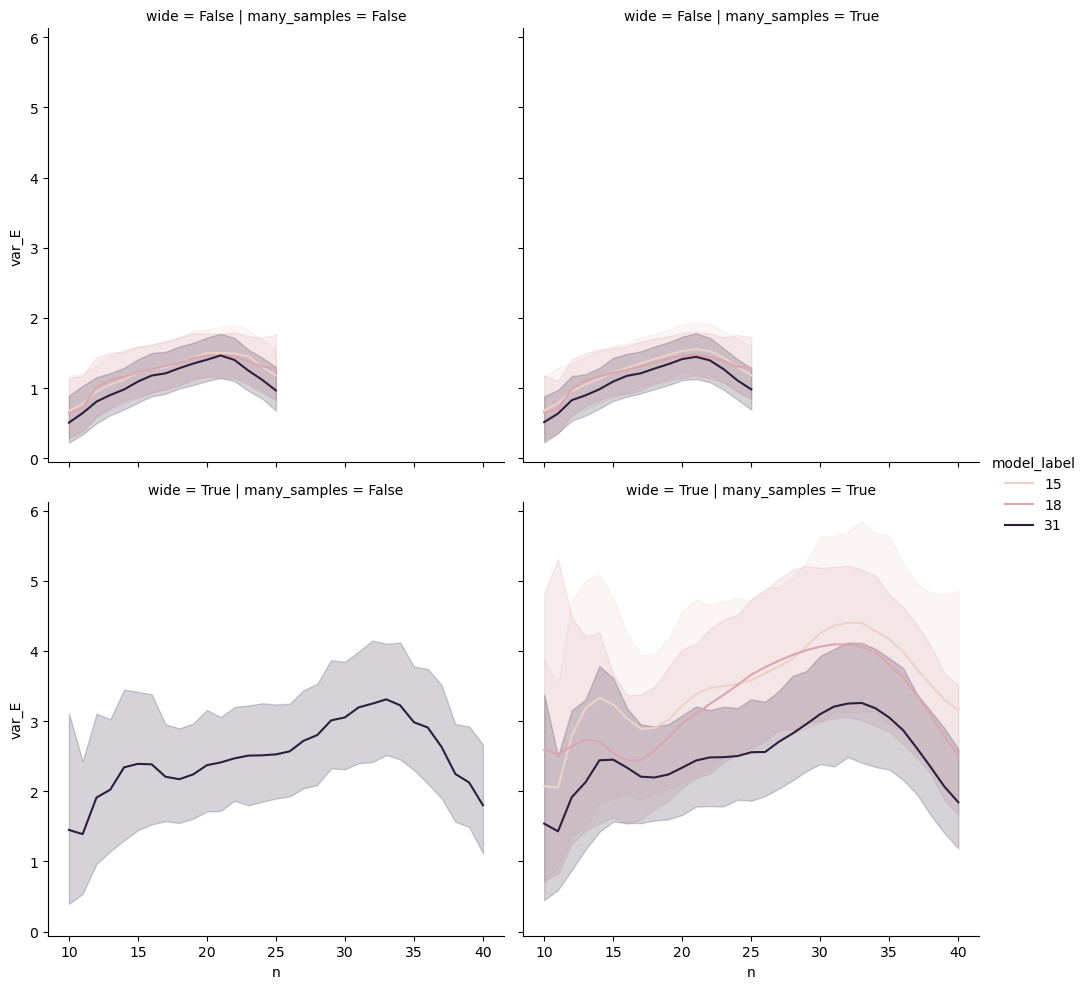

In [32]:
p = pars.groupby(['subject', 'n', 'model_label', 'many_samples', 'wide'])['var_E'].mean().reset_index()

sns.relplot(x='n', y='var_E', hue='model_label', col='many_samples', row='wide', data=p, kind='line')

In [33]:
p.query('n == 10.0').groupby(['model_label', 'many_samples', 'wide', 'subject']).size().unstack(['model_label', 'many_samples', 'wide'])

model_label     15                18                31                  
many_samples False True        False True        False       True       
wide         False False True  False False True  False True  False True 
subject                                                                 
1                1     1     1     1     1     1     1     1     1     1
2                1     1     1     1     1     1     1     1     1     1
3                1     1     1     1     1     1     1     1     1     1
4                1     1     1     1     1     1     1     1     1     1
5                1     1     1     1     1     1     1     1     1     1
6                1     1     1     1     1     1     1     1     1     1
7                1     1     1     1     1     1     1     1     1     1
8                1     1     1     1     1     1     1     1     1     1
9                1     1     1     1     1     1     1     1     1     1
10               1     1     1     1     1     1     1     1     1     1
12               1     1     1     1     1     1     1     1     1     1
13               1     1     1     1     1     1     1     1     1     1
14               1     1     1     1     1     1     1     1     1     1
15               1     1     1     1     1     1     1     1     1     1
16               1     1     1     1     1     1     1     1     1     1
17               1     1     1     1     1     1     1     1     1     1
18               1     1     1     1     1     1     1     1     1     1
19               1     1     1     1     1     1     1     1     1     1
20               1     1     1     1     1     1     1     1     1     1
21               1     1     1     1     1     1     1     1     1     1
22               1     1     1     1     1     1     1     1     1     1
24               1     1     1     1     1     1     1     1     1     1
25               1     1     1     1     1     1     1     1     1     1
26               1     1     1     1     1     1     1     1     1     1
27               1     1     1     1     1     1     1     1     1     1
28               1     1     1     1     1     1     1     1     1     1
29               1     1     1     1     1     1     1     1     1     1
30               1     1     1     1     1     1     1     1     1     1
31               1     1     1     1     1     1     1     1     1     1
32               1     1     1     1     1     1     1     1     1     1
33               1     1     1     1     1     1     1     1     1     1
34               1     1     1     1     1     1     1     1     1     1
35               1     1     1     1     1     1     1     1     1     1
36               1     1     1     1     1     1     1     1     1     1
37               1     1     1     1     1     1     1     1     1     1
38               1     1     1     1     1     1     1     1     1     1
39               1     1     1     1     1     1     1     1     1     1
40               1     1     1     1     1     1     1     1     1     1
41               1     1     1     1     1     1     1     1     1     1

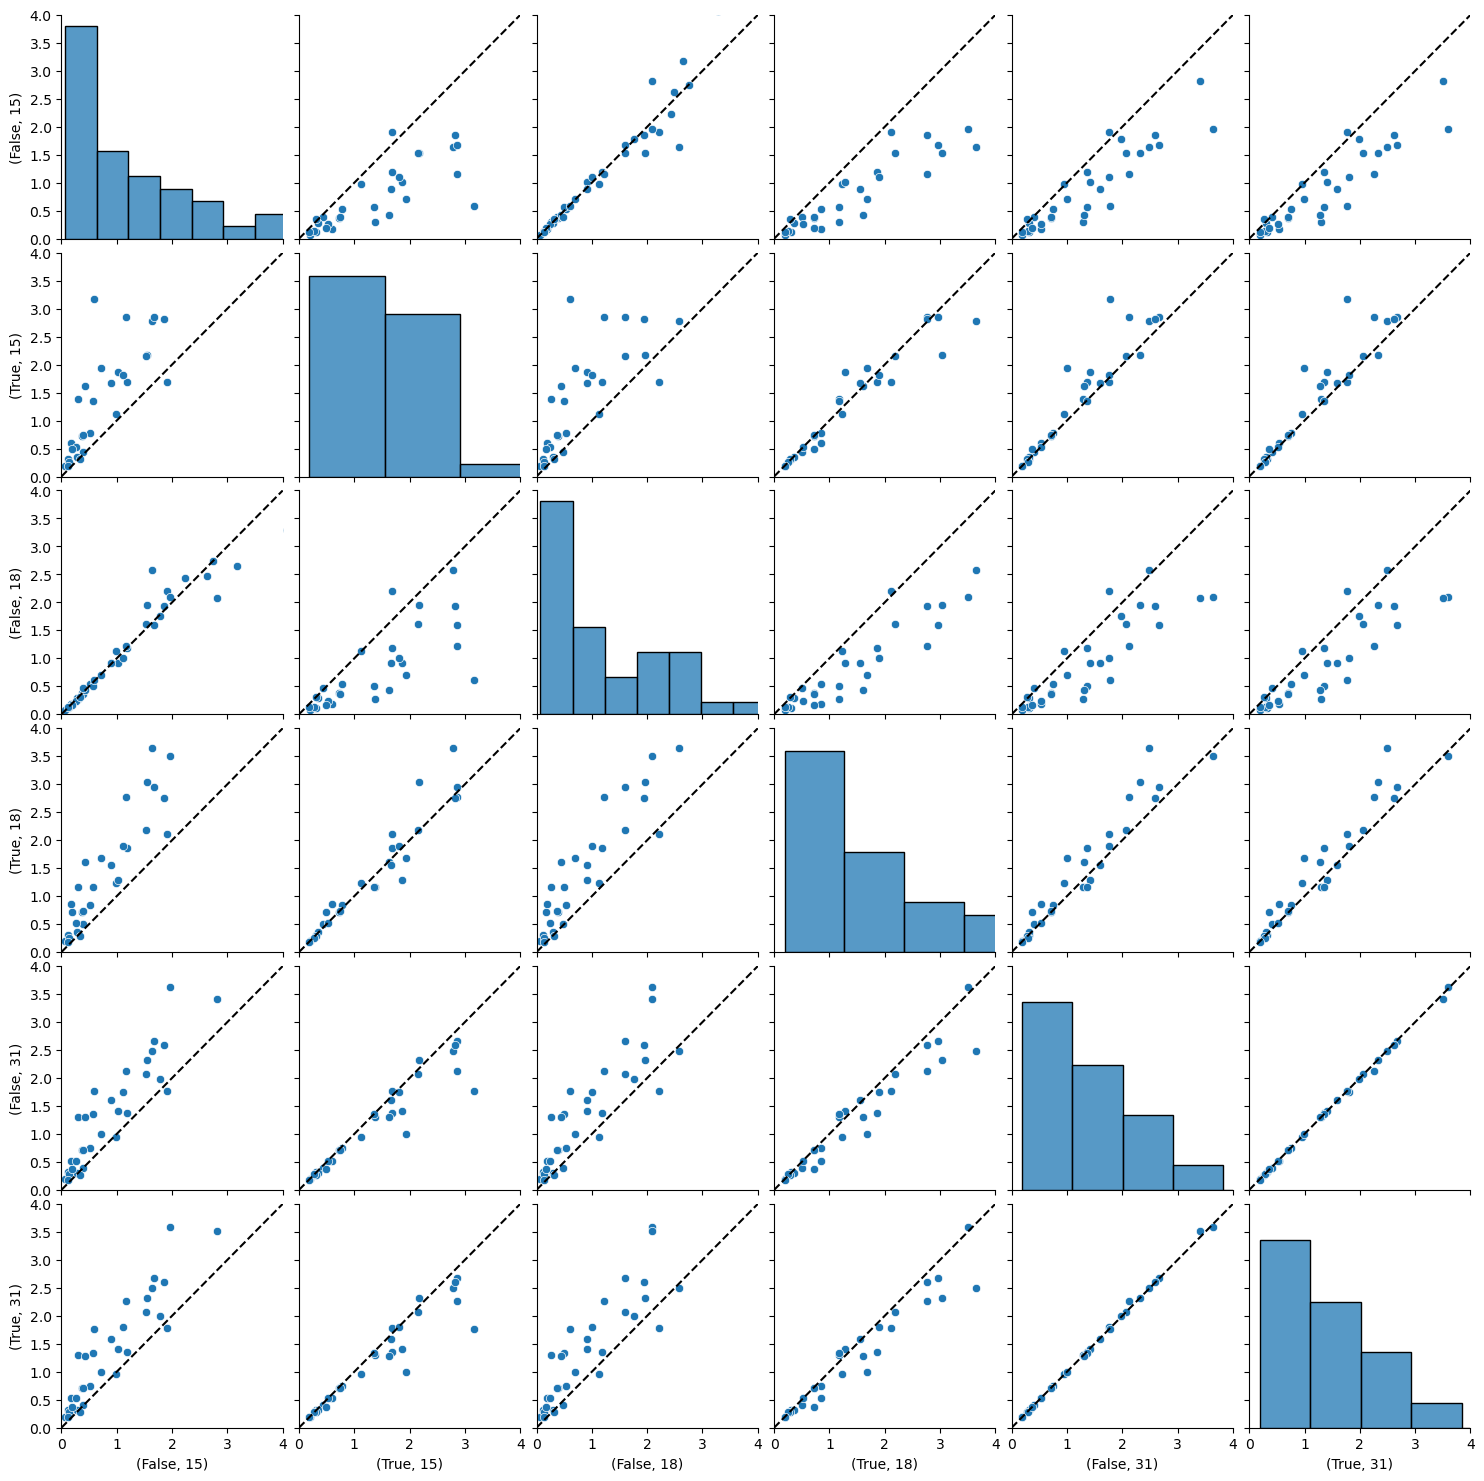

In [35]:
import matplotlib.pyplot as plt
g = sns.pairplot(pars.groupby(['subject', 'model_label', 'many_samples'])[['var_E']].mean().unstack(['many_samples', 'model_label'])['var_E'])

g.map_offdiag(lambda *args, **kwargs: plt.axline(xy1=(0,0), slope=1., c='k', ls='--'))

g.set(xlim=(0, 4), ylim=(0, 4))

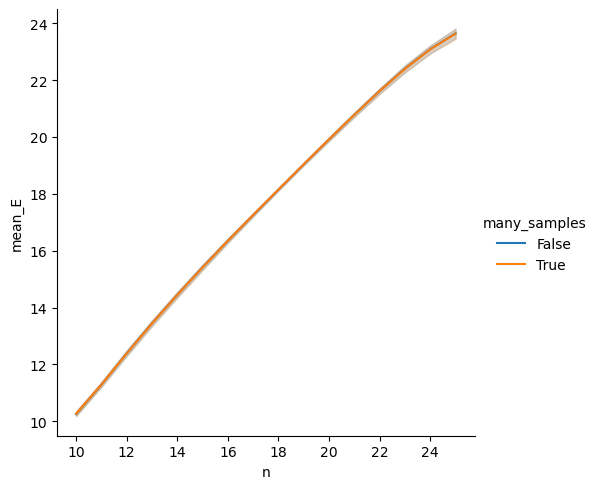

In [ ]:
p = pars.groupby(['subject', 'model_label', 'smoothed', 'many_samples', 'n'])[['mean_E']].mean()

sns.relplot(x='n', y='mean_E', hue='many_samples', data=p.reset_index(), kind='line')

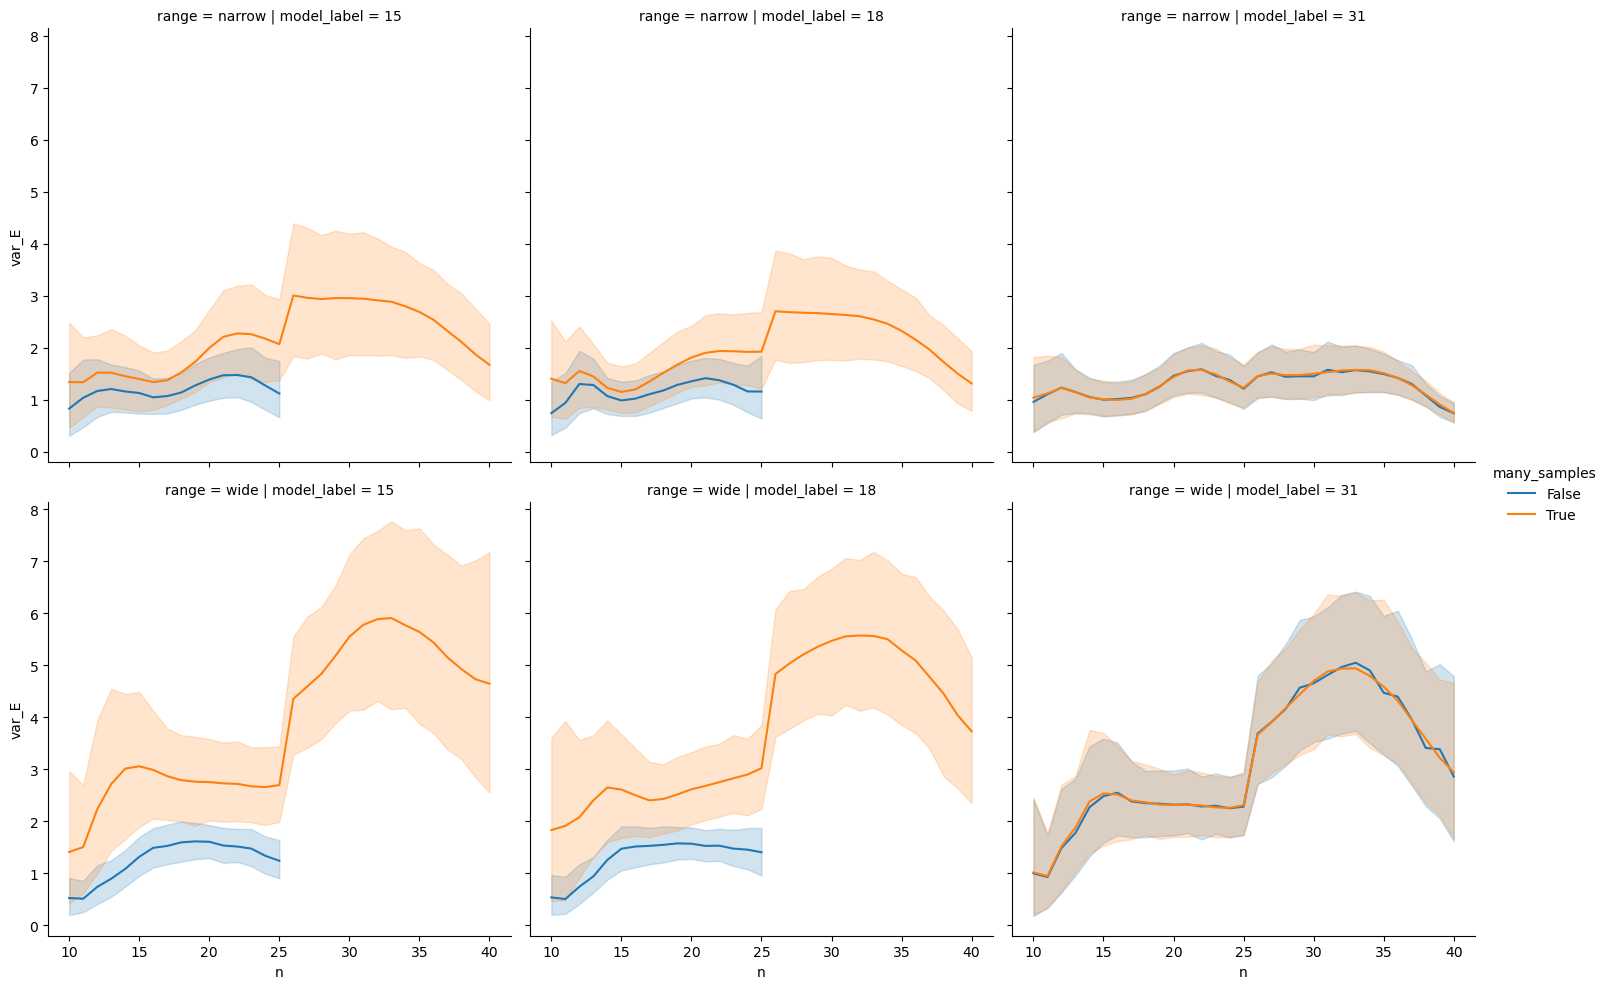

In [37]:
p = pars.groupby(['subject', 'model_label', 'smoothed', 'many_samples', 'n', 'range'])[['var_E']].mean()

sns.relplot(x='n', y='var_E', hue='many_samples', data=p.reset_index(), kind='line', row='range', col='model_label')